# ⚙️ **Predictive Maintenance: Failure Prediction and Anomaly Detection for Industrial Machines**  

---

### 📝 **Introduction**  
This project explores the application of **Machine Learning** for predictive maintenance in an industrial context. The objectives are twofold:  
- **Predict potential machine failures** using supervised classification models (**XGBoost, Random Forest**)  
- **Detect subtle anomalies** not visible to traditional systems using unsupervised models (**Isolation Forest**)  

---

### 🛠️ **Table of Contents**  
1. 📊 **Data Consultation and Preparation**  
2. 📊 **Exploratory Data Analysis (EDA)**  
3. 🟦 **Supervised Classification (Failure Prediction and Type Identification)**  
4. 📈 **Model Evaluation and Results Interpretation**  
5. 🟢 **Anomaly Detection (Unsupervised Learning)**  
6. 📊 **Insights and Visualization**  
7. 🚀 **Recommendations and Action Plan**


# Installing libraries

In [16]:
%pip install -q pandas
%pip install -q hvplot
%pip install -q matplotlib
%pip install -q seaborn
%pip install -q scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Library Importation

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

# Data Consultation

In [18]:
PDM_data = pd.read_csv('predictive_maintenance.csv')
type(PDM_data)

pandas.core.frame.DataFrame

In [20]:
PDM_data['Temp_Diff'] = PDM_data['Process temperature [K]'] - PDM_data['Air temperature [K]']
PDM_data.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temp_Diff
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,10.5
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,10.5
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,10.5
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,10.4
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,10.5


In [21]:
PDM_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
 10  Temp_Diff                10000 non-null  float64
dtypes: float64(4), int64(4), object(3)
memory usage: 859.5+ KB


In [22]:
PDM_data_drop = PDM_data.drop(columns= ["UDI", "Product ID" , "Type" , "Failure Type", "Target"])
PDM_data_drop.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,10.000630
std,2.000259,1.483734,179.284096,9.968934,63.654147,1.001094
min,295.300000,305.700000,1168.000000,3.800000,0.000000,7.600000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,9.300000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,9.800000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,11.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,12.100000


In [23]:
pd.unique(PDM_data["Failure Type"])

array(['No Failure', 'Power Failure', 'Tool Wear Failure',
       'Overstrain Failure', 'Random Failures',
       'Heat Dissipation Failure'], dtype=object)

# 📊 Analyse exploratoire des données (AED)

In [24]:
PDM_data.hvplot.hist(y="Torque [Nm]", bins=30, title="Distribution de Torque [Nm]")

:Histogram   [Torque [Nm]]   (Count)

In [25]:
PDM_data.hvplot.scatter(x='Rotational speed [rpm]', y='Torque [Nm]', title="Vitesse vs Couple")

:Scatter   [Rotational speed [rpm]]   (Torque [Nm])

In [26]:
PDM_data.hvplot.hist(y="Temp_Diff", bins=30, title="Distribution de la Différence de Température")

:Histogram   [Temp_Diff]   (Count)

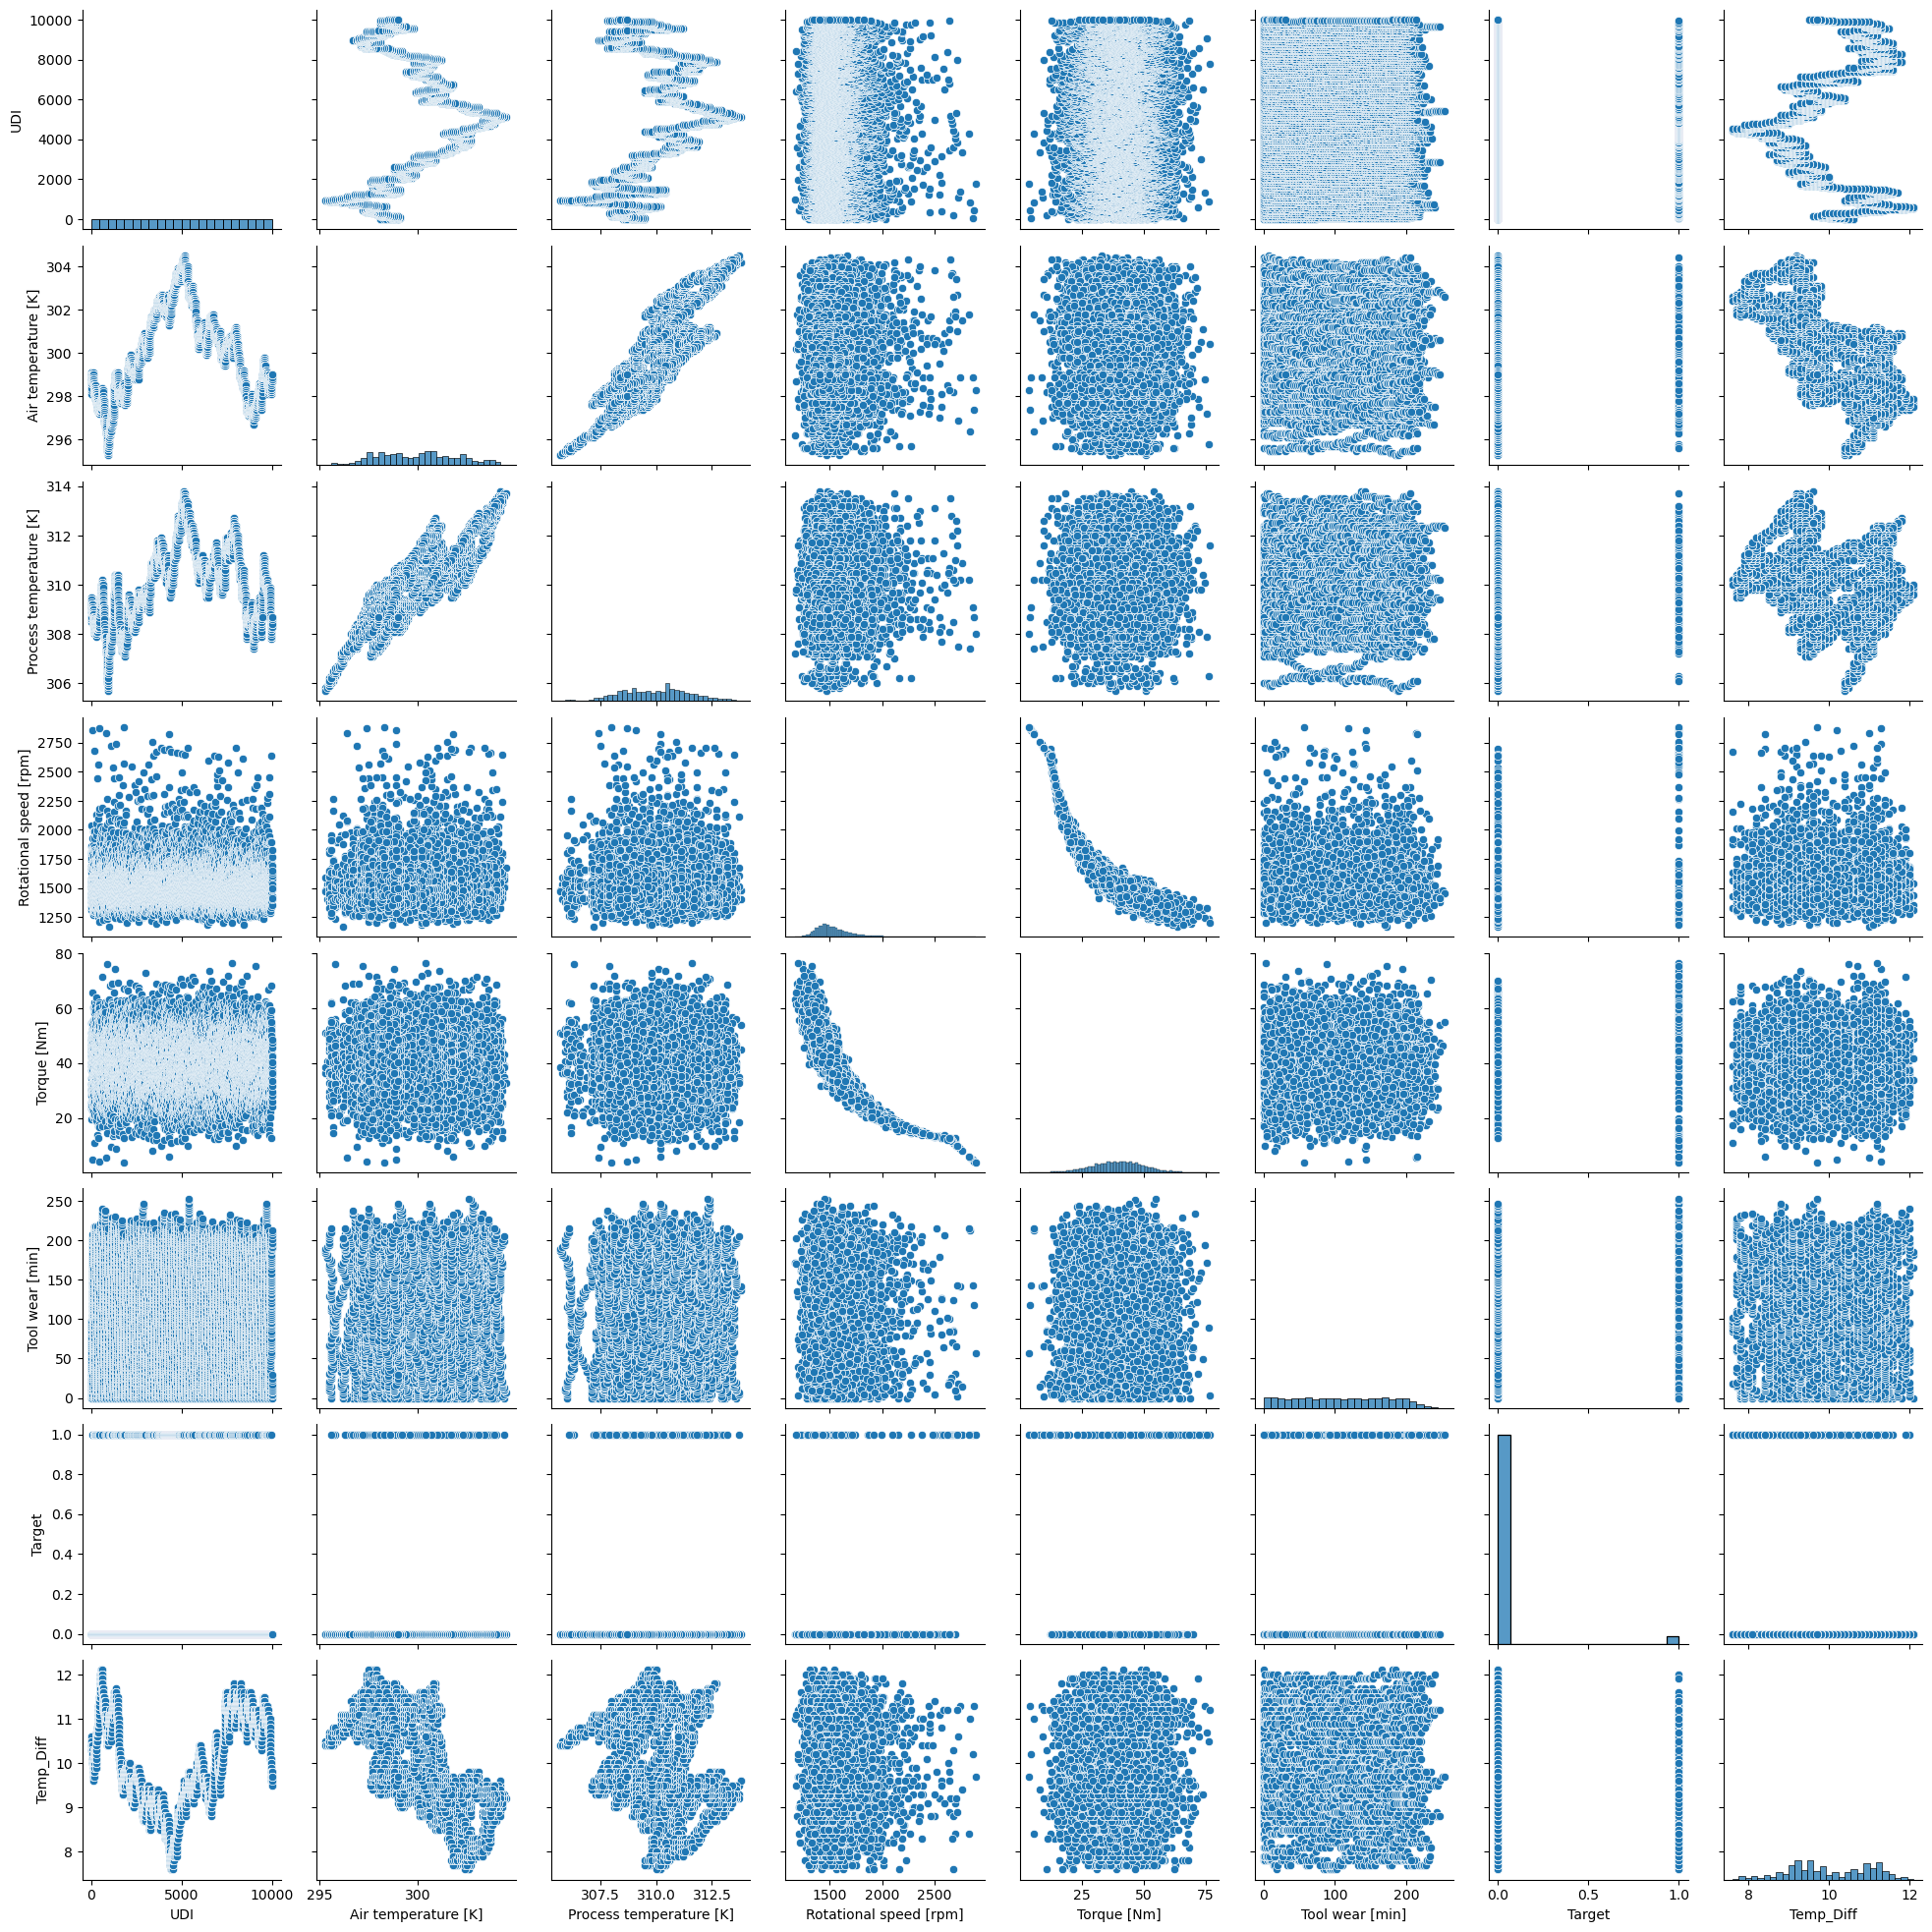

In [27]:
sns_plot = sns.pairplot(PDM_data.select_dtypes(include='number'))

Text(0.5, 1.0, 'Heatmap des Corrélations')

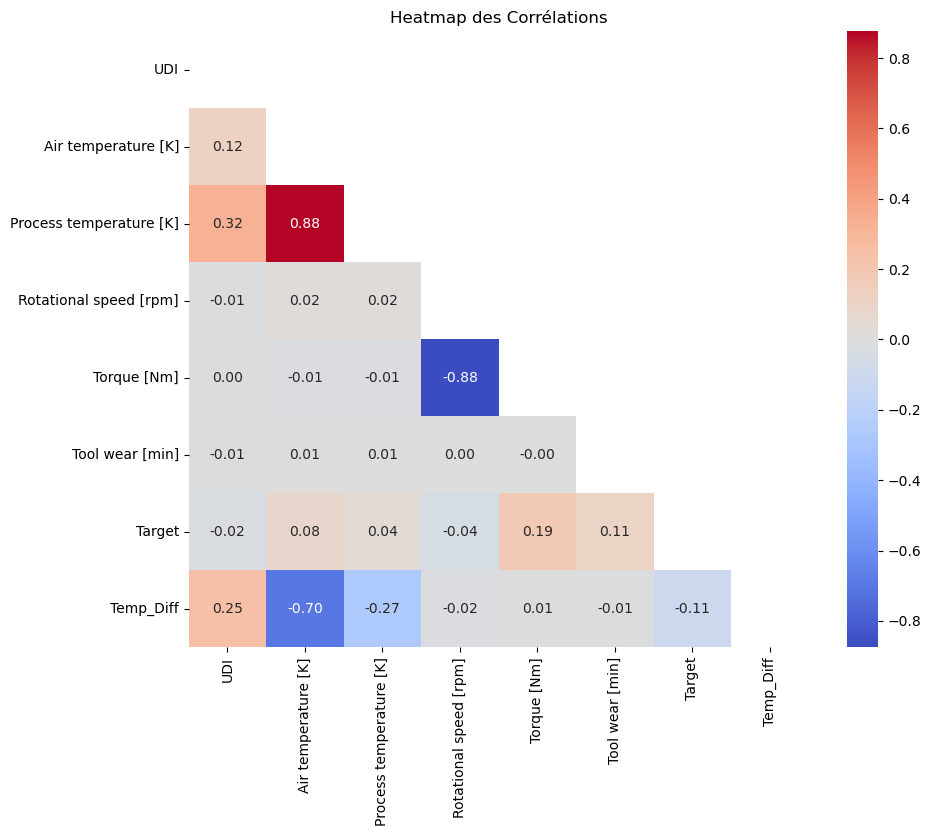

In [36]:
numeric_data = PDM_data.select_dtypes(include='number')
calc = numeric_data.corr()
mask = np.triu(np.ones_like(calc, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax, mask=mask)
plt.title("Correlation heatmap")

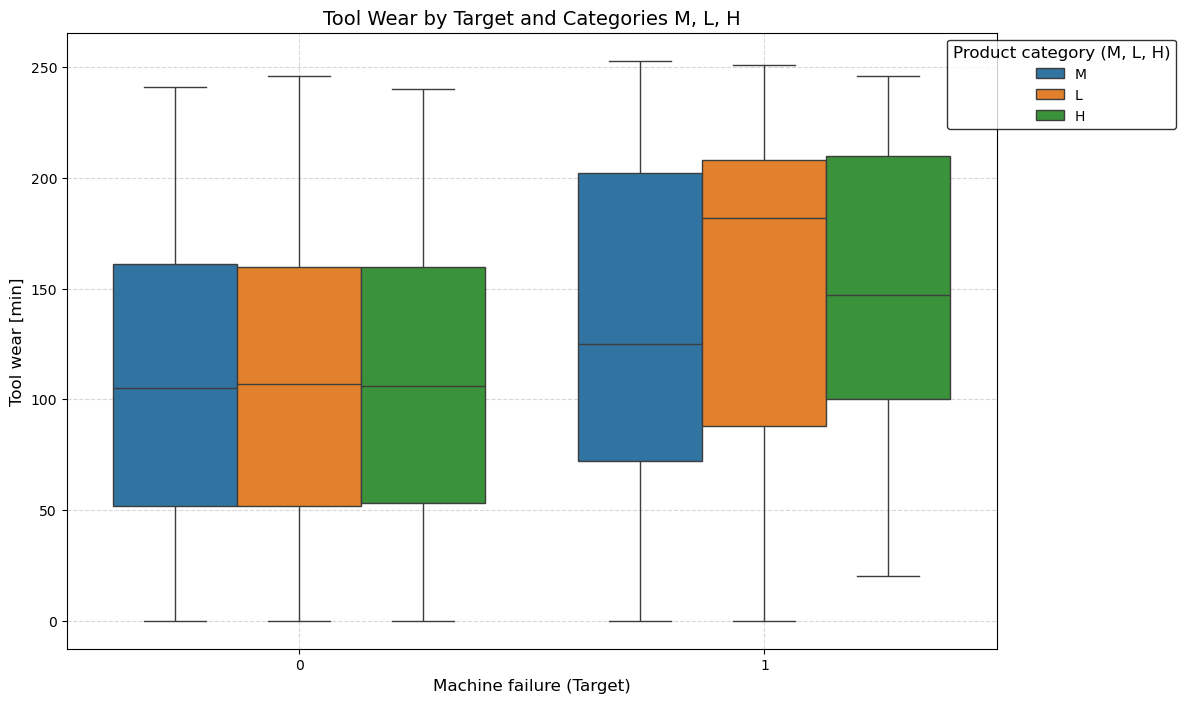

In [39]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(data=PDM_data, x='Target', y='Tool wear [min]', hue='Type', ax=ax)
plt.title('Tool Wear by Target and Categories M, L, H', fontsize=14)
plt.xlabel('Machine failure (Target)', fontsize=12)
plt.ylabel('Tool wear [min]', fontsize=12)
legend = ax.legend(title='Product category (M, L, H)', fontsize=10, title_fontsize=12, loc='upper right', bbox_to_anchor=(1.2, 1))
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
ax.grid(True, linestyle='--', alpha=0.5)
plt.savefig("boxplot_tool_wear_MLH.png", bbox_inches='tight')

Text(0.5, 1.0, 'Relationship between Rotational Speed, Torque and Tool Wear with Target')

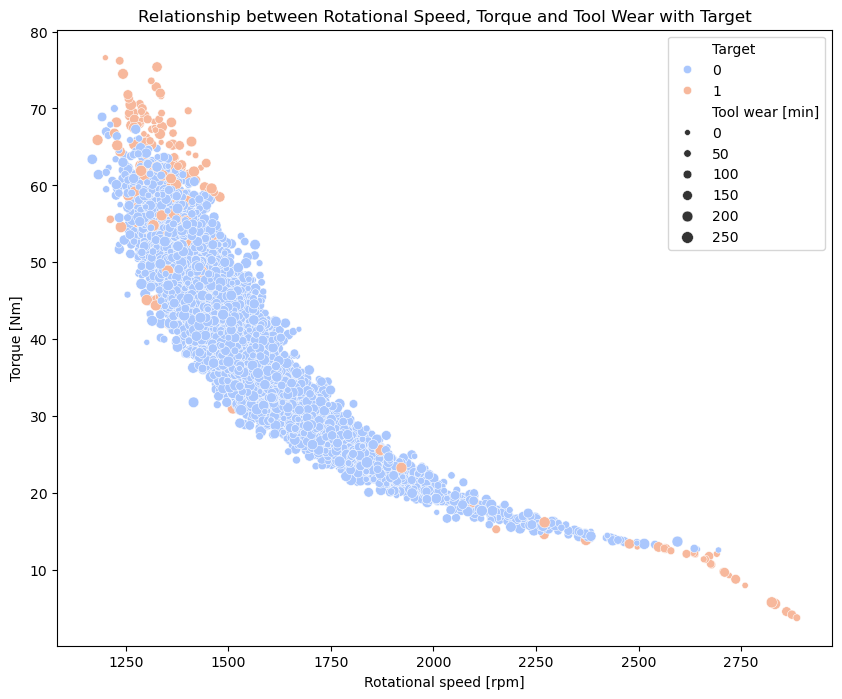

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=PDM_data, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Target', size='Tool wear [min]', palette='coolwarm', ax=ax)
plt.title('Relationship between Rotational Speed, Torque and Tool Wear with Target')

Text(0.5, 1.0, 'Relation entre Différence Température et Tool Wear par Target')

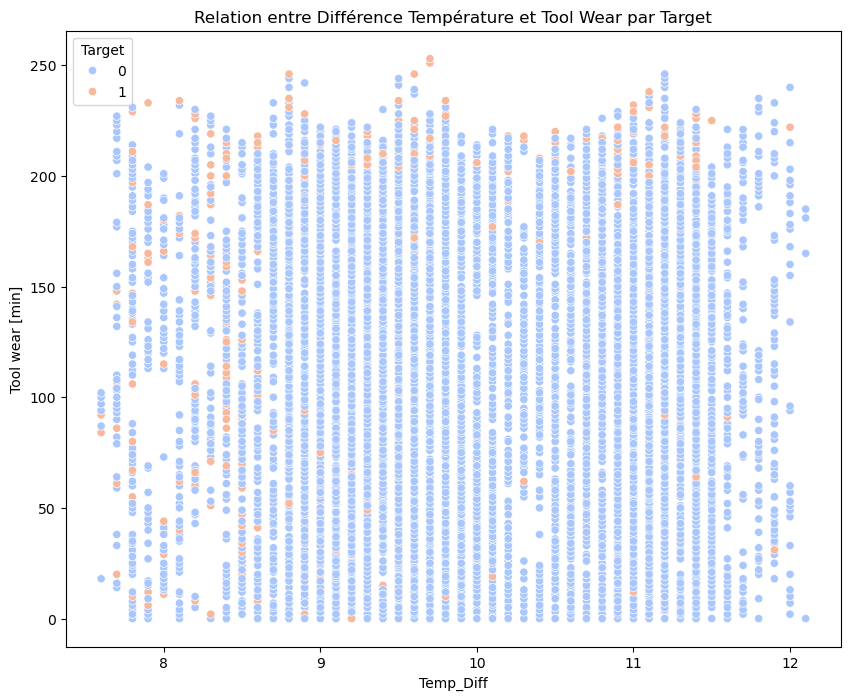

In [48]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=PDM_data, x='Temp_Diff', y='Tool wear [min]', hue='Target', palette='coolwarm', ax=ax)
plt.title('Relation entre Différence Température et Tool Wear par Target')

Text(0.5, 1.0, 'Distribution de Torque en Fonction de Target')

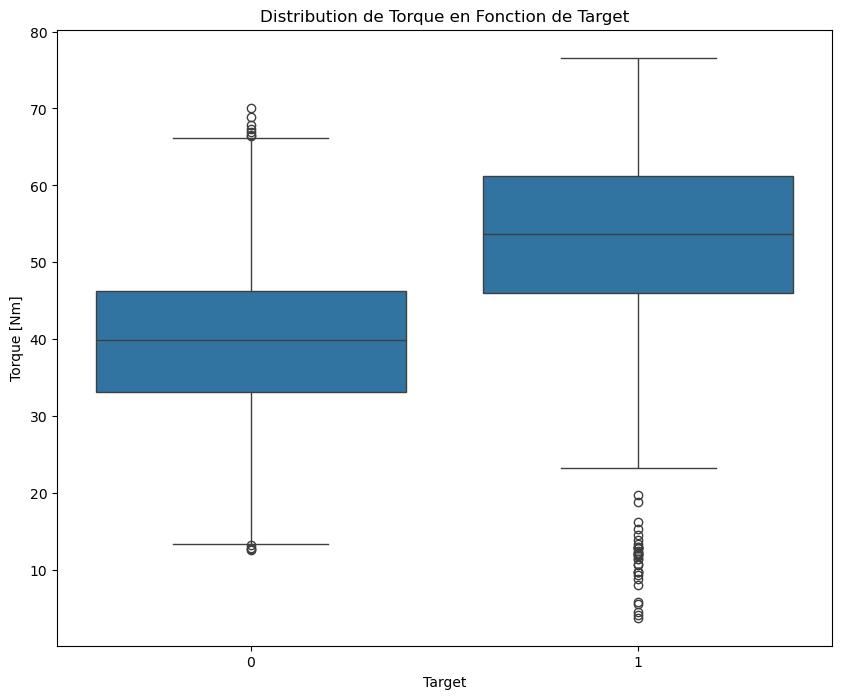

In [45]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=PDM_data, x='Target', y='Torque [Nm]', ax=ax)
plt.title('Distribution de Torque en Fonction de Target')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'No Failure'),
  Text(1, 0, 'Power Failure'),
  Text(2, 0, 'Tool Wear Failure'),
  Text(3, 0, 'Overstrain Failure'),
  Text(4, 0, 'Random Failures'),
  Text(5, 0, 'Heat Dissipation Failure')])

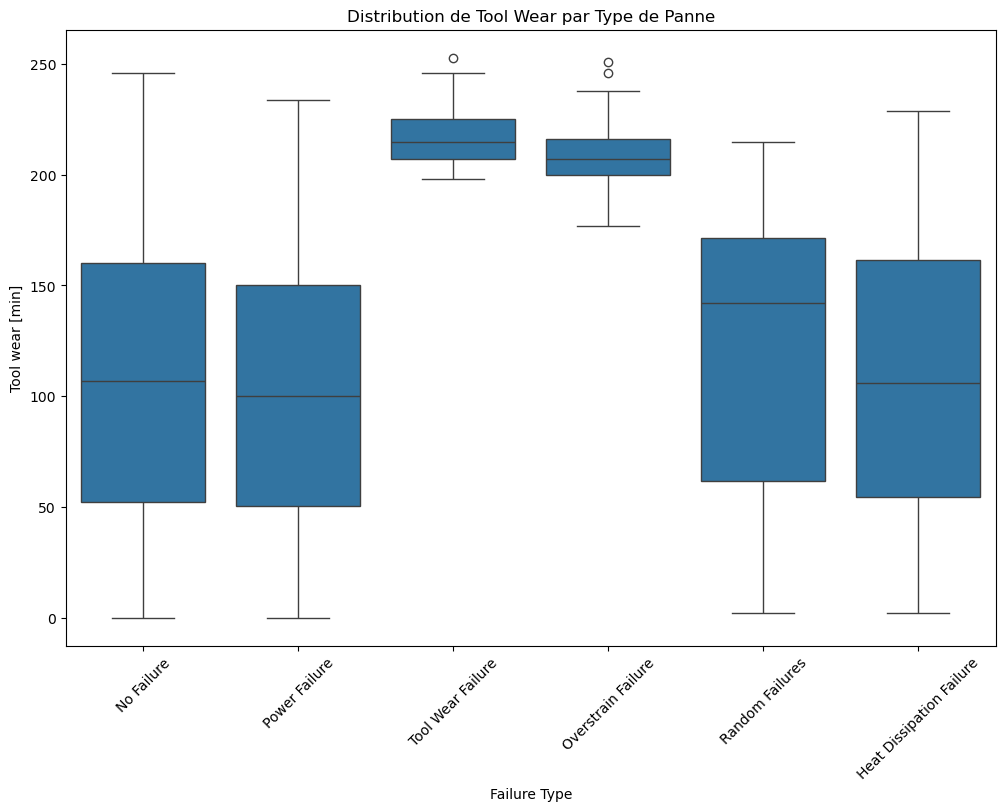

In [50]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(data=PDM_data, x='Failure Type', y='Tool wear [min]')
plt.title('Distribution de Tool Wear par Type de Panne')
plt.xticks(rotation=45)

In [59]:
import hvplot.pandas
# Exclure un label spécifique (ex: 'No Failure')
filtered_data = PDM_data[PDM_data['Failure Type'] != 'No Failure']

# Créer l'histogramme interactif avec hvPlot
plot = filtered_data.hvplot.hist(
    y='Torque [Nm]',        # Colonne pour l'histogramme
    by='Failure Type',      # Crée un histogramme par catégorie (équivalent hue)
    stacked=True,           # Empile les barres (multiple='stack')
    bins=30,               # Nombre de bacs (bins)
    cmap='Category10',     # Palette de couleurs
    title='Distribution de Torque par Type de Panne',
    legend='top',          # Position de la légende
    responsive=True,       # Adaptation dynamique à la taille du conteneur
    height=500,
    width=700
).opts(
    active_tools=['box_zoom', 'pan'], 
    toolbar='above'
)

# Afficher le graphique
plot


:NdOverlay   [Failure Type]
   :Histogram   [Torque [Nm]]   (Count)

Text(0.5, 1.0, 'Relation entre Vitesse de Rotation et Torque par Type de Panne')

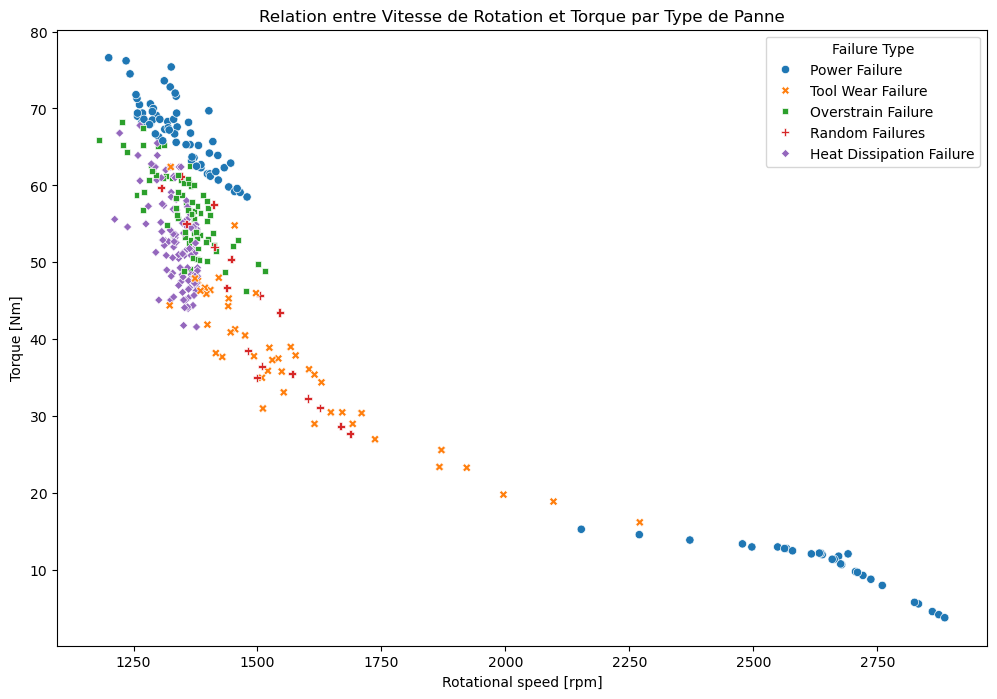

In [61]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=filtered_data, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Failure Type', style='Failure Type')
plt.title('Relation entre Vitesse de Rotation et Torque par Type de Panne')